In [ ]:
# Find the zipfile here: https://drive.google.com/file/d/1RMIopnMkLLj44VzprH4VbZDReXU7Cr4Y/view?usp=drive_link

## Install Required Packages

Run this cell first to install the required dependencies.

In [2]:
%pip install pandas matplotlib

  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 62.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 59.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 55.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 57.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 51.1 MB/s  0:00:00
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
Using cached tzdata-2025.2-py2.py3-none-any.whl (347 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11/11 [matplotlib]0m 10/11 [matplotlib]tools]
Note: you may need to restart the kernel to use updated packages.


# NICAR-L Listserv Post Analysis

This notebook analyzes LISTSERV archive files from the NICAR-L mailing list and counts the number of posts by month from 2002 to 2023.

## Import Required Libraries

In [3]:
import os
import re
from collections import defaultdict
from pathlib import Path
import pandas as pd

## Define Parsing Functions

In [4]:
def parse_log_file(filepath):
    """
    Parse a single LISTSERV log file and count posts.
    
    Posts are delimited by lines of equal signs (=====).
    Each post has a Date: field at the beginning.
    
    Returns the count of posts in this file.
    """
    count = 0
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        content = f.read()
        # Count the number of separator lines (each post starts with one)
        separators = content.count('=' * 73)  # The separator is 73 '=' characters
        count = separators
    return count


def extract_year_month_from_filename(filename):
    """
    Extract year and month from log filename.
    
    Supports two formats:
    - Lowercase: nicar-l.logYYMM (e.g., nicar-l.log0207 -> 2002, 7)
    - Uppercase: NICAR-L.LOGYYMM (e.g., NICAR-L.LOG1408 -> 2014, 8)
    """
    # Try lowercase format first
    match = re.match(r'nicar-l\.log(\d{2})(\d{2})', filename, re.IGNORECASE)
    if match:
        year_suffix = int(match.group(1))
        month = int(match.group(2))
        
        # Determine century (assuming 00-89 is 2000s, 90-99 is 1990s)
        if year_suffix >= 90:
            year = 1900 + year_suffix
        else:
            year = 2000 + year_suffix
        
        return year, month
    return None, None

## Parse All Log Files

In [5]:
# Path to the archives directory
archives_dir = Path("NICAR-L_2023-08-29/archives")

if not archives_dir.exists():
    print(f"Error: Archives directory not found at {archives_dir}")
else:
    # Dictionary to store counts by year-month
    monthly_counts = defaultdict(int)
    
    # Get all log files (both lowercase and uppercase naming conventions)
    log_files = sorted([f for f in archives_dir.iterdir() 
                       if re.match(r'nicar-l\.log\d{4}', f.name, re.IGNORECASE)])
    
    print(f"Found {len(log_files)} log files to process...")
    
    # Process each log file
    for log_file in log_files:
        year, month = extract_year_month_from_filename(log_file.name)
        if year and month:
            count = parse_log_file(log_file)
            monthly_counts[(year, month)] = count
    
    print(f"Processed {len(monthly_counts)} months of data")

Found 254 log files to process...
Processed 254 months of data


## Create DataFrame

In [6]:
# Create a DataFrame from the monthly counts
data = []
for (year, month), count in sorted(monthly_counts.items()):
    date_str = f"{month:02d}/{year}"
    data.append({
        'Date': date_str,
        'Year': year,
        'Month': month,
        'Posts': count
    })

df = pd.DataFrame(data)

# Display the first few rows
print(f"Data shape: {df.shape}")
print(f"\nFirst 10 rows:")
df.head(10)

Data shape: (254, 4)

First 10 rows:


,Date,Year,Month,Posts
0,07/2002,2002,7,135
1,08/2002,2002,8,269
2,09/2002,2002,9,256
3,10/2002,2002,10,345
4,11/2002,2002,11,361
5,12/2002,2002,12,202
6,01/2003,2003,1,427
7,02/2003,2003,2,410
8,03/2003,2003,3,336
9,04/2003,2003,4,417


## Summary Statistics

In [7]:
total_posts = df['Posts'].sum()
avg_posts = df['Posts'].mean()
max_posts = df['Posts'].max()
min_posts = df['Posts'].min()
max_date = df[df['Posts'] == max_posts]['Date'].values[0]
min_date = df[df['Posts'] == min_posts]['Date'].values[0]

print(f"Total posts: {total_posts:,}")
print(f"Time period: {df['Date'].iloc[0]} to {df['Date'].iloc[-1]}")
print(f"Total months: {len(df)}")
print(f"Average posts per month: {avg_posts:.1f}")
print(f"Maximum posts: {max_posts:,} ({max_date})")
print(f"Minimum posts: {min_posts:,} ({min_date})")

Total posts: 84,423
Time period: 07/2002 to 08/2023
Total months: 254
Average posts per month: 332.4
Maximum posts: 921 (03/2014)
Minimum posts: 15 (06/2023)


## Display Full Data Table

In [8]:
# Display all data with formatted numbers
df_display = df[['Date', 'Posts']].copy()
df_display

,Date,Posts
0,07/2002,135
1,08/2002,269
2,09/2002,256
3,10/2002,345
4,11/2002,361
...,...,...
249,04/2023,37
250,05/2023,42
251,06/2023,15
252,07/2023,25


## Visualize Posts Over Time

Matplotlib is building the font cache; this may take a moment.


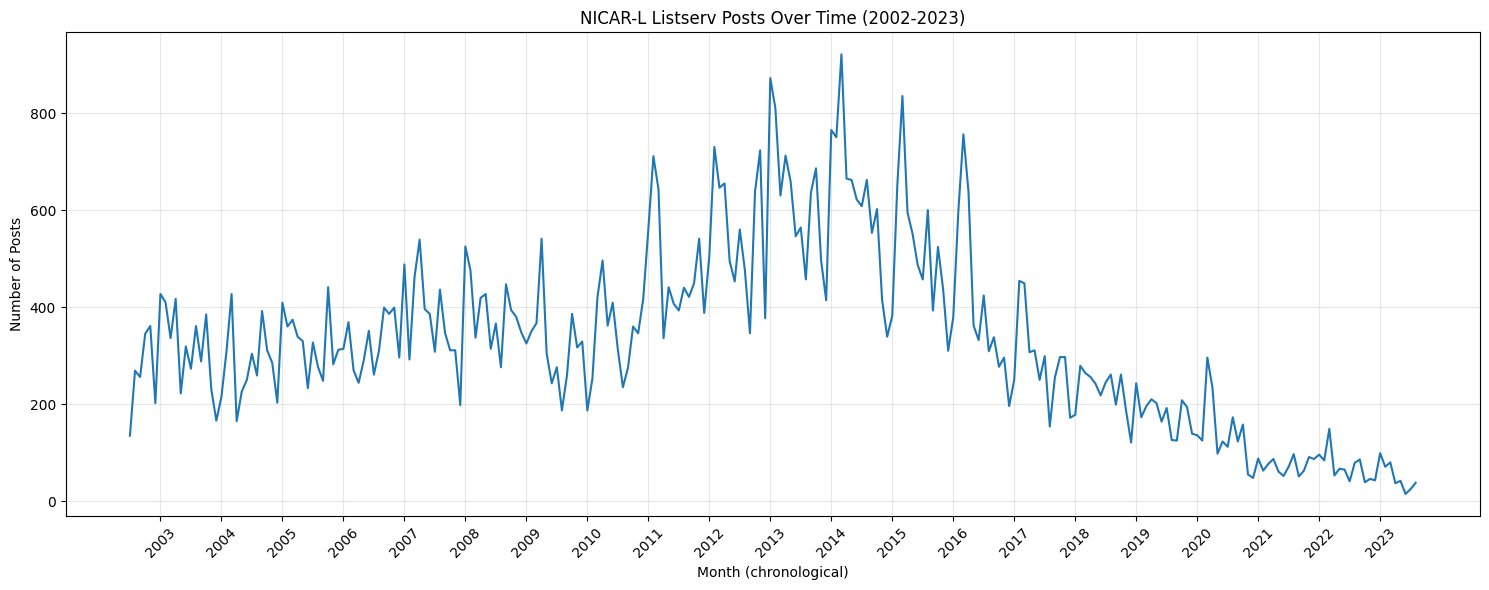

In [9]:
import matplotlib.pyplot as plt

# Create a time series plot
plt.figure(figsize=(15, 6))
plt.plot(range(len(df)), df['Posts'], linewidth=1.5)
plt.xlabel('Month (chronological)')
plt.ylabel('Number of Posts')
plt.title('NICAR-L Listserv Posts Over Time (2002-2023)')
plt.grid(True, alpha=0.3)

# Add year markers on x-axis
year_changes = df[df['Month'] == 1].index.tolist()
year_labels = df[df['Month'] == 1]['Year'].tolist()
plt.xticks(year_changes, year_labels, rotation=45)

plt.tight_layout()
plt.show()

## Posts by Year


Total posts by year:

 Year  Total Posts
 2002         1568
 2003         3835
 2004         3346
 2005         3932
 2006         3889
 2007         4474
 2008         4709
 2009         3885
 2010         4074
 2011         5730
 2012         6604
 2013         7482
 2014         7564
 2015         6224
 2016         4904
 2017         3495
 2018         2711
 2019         2172
 2020         1682
 2021          888
 2022          848
 2023          407


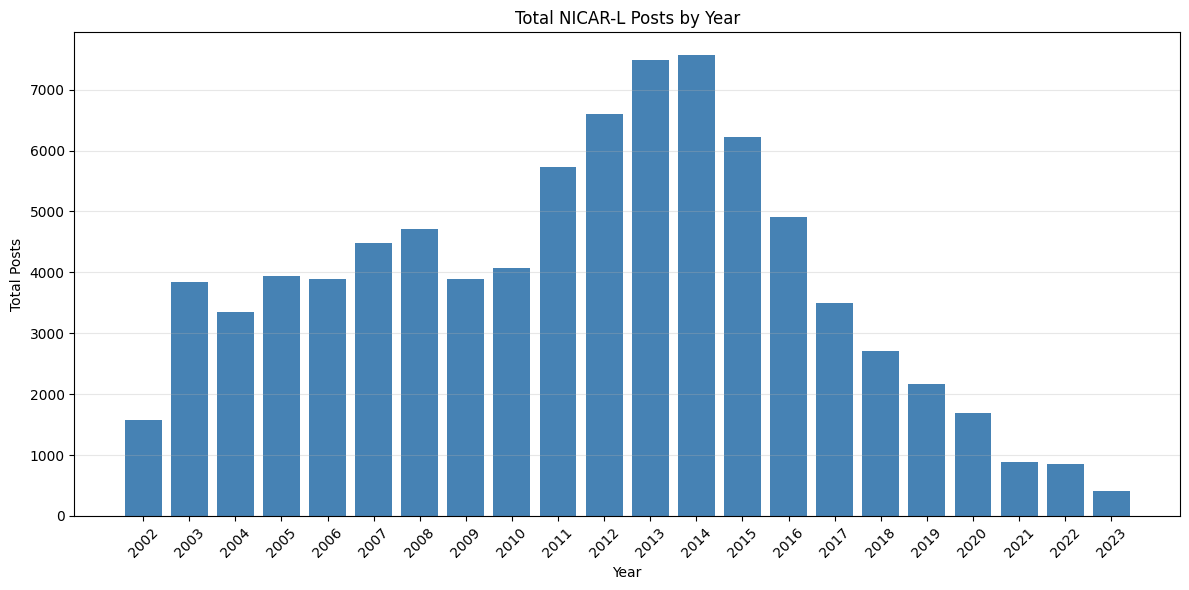

In [10]:
# Group by year and sum posts
yearly_posts = df.groupby('Year')['Posts'].sum().reset_index()
yearly_posts.columns = ['Year', 'Total Posts']

print("\nTotal posts by year:\n")
print(yearly_posts.to_string(index=False))

# Visualize
plt.figure(figsize=(12, 6))
plt.bar(yearly_posts['Year'], yearly_posts['Total Posts'], color='steelblue')
plt.xlabel('Year')
plt.ylabel('Total Posts')
plt.title('Total NICAR-L Posts by Year')
plt.xticks(yearly_posts['Year'], rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()